# Data Storytelling

In [19]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt

df = pd.read_csv('../data_files/combined_services_for_map.csv')

1.

In [20]:
top_3 = duckdb.sql("""
    SELECT kategori, COUNT(*) as antal
    FROM df
    GROUP BY kategori
    ORDER BY antal DESC
    LIMIT 3
""").df()

top_3

,kategori,antal
0,Lekplats,306
1,Restaurang & Snabbmat,301
2,förskola,180


In [21]:
bottom_3 = duckdb.sql("""
    SELECT kategori, COUNT(*) as antal
    FROM df
    WHERE kategori IS NOT NULL
    GROUP BY kategori
    ORDER BY antal ASC
    LIMIT 3
""").df()

bottom_3

,kategori,antal
0,Sjukhus,2
1,Fysioterapeut,3
2,Biograf,4


In [22]:
all = duckdb.sql("""
    SELECT kategori, COUNT(*) as antal
    FROM df
    WHERE kategori IS NOT NULL
    GROUP BY kategori
    ORDER BY antal DESC
""").df()

all

,kategori,antal
0,Lekplats,306
1,Restaurang & Snabbmat,301
2,förskola,180
3,Park,128
4,Kafé,61
5,Gym/Utomhusgym,59
6,grundskolor,55
7,Matbutik,44
8,Tandläkare,24
9,Bensinmack,19


In [23]:
top_cats    = top_3["kategori"].tolist()
bottom_cats = bottom_3["kategori"].tolist()

def get_color(Kategori):
    if Kategori in top_cats:
        return "#1b3a5c"
    elif Kategori in bottom_cats:
        return "#9b3a2e"
    return "#C9C9C9"

all["färg"] = all["kategori"].map(get_color)

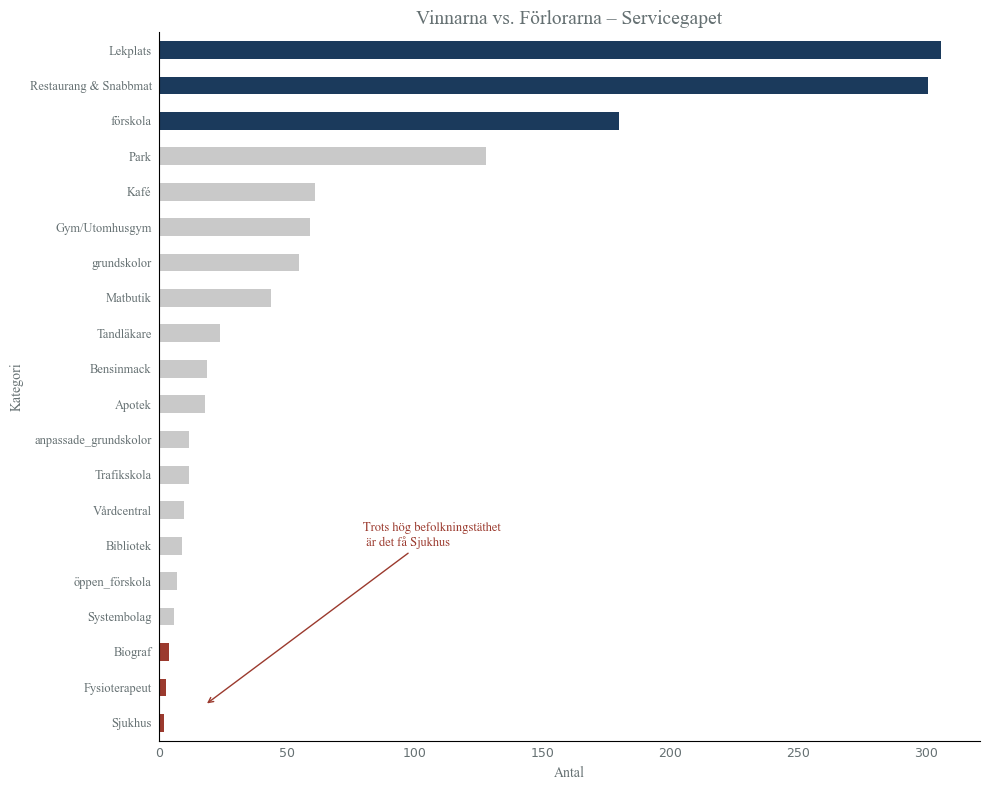

In [24]:
ax = (all
    .sort_values("antal")
    .plot.barh(
        x="kategori",
        y="antal",
        ylabel="Kategori",
        xlabel="Antal",
        color=all.sort_values("antal")["färg"],
        figsize=(10, 8),
        legend=False,
        title="Vinnarna vs. Förlorarna – Servicegapet"
    )
)


ax.annotate(
    "Trots hög befolkningstäthet\n är det få Sjukhus",
    xy=(18, 0.5), xytext=(80, 5),
    fontsize=9, color="#9b3a2e",
    family="Times",
    arrowprops=dict(arrowstyle="->", color="#9b3a2e"),

)

ax.set_title("Vinnarna vs. Förlorarna – Servicegapet", fontfamily="Times New Roman", fontsize=14, color = "#657072")
ax.set_xlabel("Antal", fontfamily="Times New Roman", color = "#657072")
ax.set_ylabel("Kategori", fontfamily="Times New Roman", color = "#657072")
ax.tick_params(axis = "both", labelsize=9, colors="#657072", length=0, pad = 5)

for label in ax.get_yticklabels():
    label.set_fontfamily("Times New Roman")

ax.spines[["top", "right"]].set_visible(False)

fig = ax.get_figure()
fig.tight_layout()
fig.savefig("servicegapet.png", dpi=150)

2.

In [25]:
df2 = pd.read_csv('../data_files/brottsstatistik_per_capita_cleaned.csv')

In [26]:
topp8 = duckdb.sql("""
    SELECT 
        b.Brottstyp,
        b."2025" as Bromma,
        h."2025" as Hagersten
    FROM df2 b
    JOIN df2 h ON b.Brottstyp = h.Brottstyp
    WHERE b.område = 'Bromma'
      AND h.område = 'Hägersten-Älvsjö'
    ORDER BY ABS(b."2025" - h."2025") DESC
    LIMIT 8
""").df()

topp8

,Brottstyp,Bromma,Hagersten
0,Skadegörelse,3957.0,5593.0
1,Misshandel,603.0,773.0
2,Hot & olaga intrång,1372.0,1507.0
3,Narkotikabrott,735.0,869.0
4,Bostadsinbrott,199.0,75.0
5,Stöld från fordon,343.0,273.0
6,Cykelstöld,600.0,570.0
7,Sexualbrott,253.0,279.0


In [27]:
topp8 = topp8.set_index("Brottstyp")
topp8_norm = topp8.div(topp8.max(axis=1), axis=0)

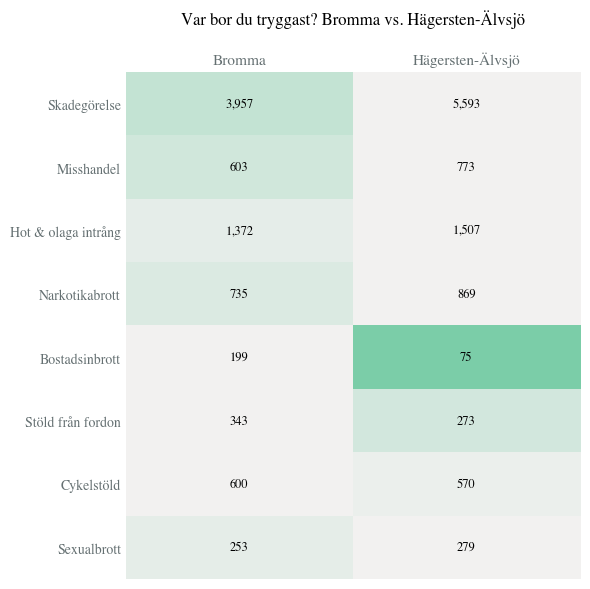

In [44]:
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams["font.family"] = "Times"

cmap = LinearSegmentedColormap.from_list("grå_grön", ["#e9e8e693", "#11af68"])
topp8_norm = 1 - topp8.div(topp8.max(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(6, 6))

im = ax.imshow(topp8_norm.values, cmap=cmap, aspect="auto", vmin=0, vmax=1)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Bromma", "Hägersten-Älvsjö"], fontsize=11, color = "#657072")
ax.set_yticks(range(len(topp8_norm)))
ax.set_yticklabels(topp8_norm.index, fontsize=10, color = "#657072")
ax.xaxis.tick_top()
ax.tick_params(length=0)

for i, brottstyp in enumerate(topp8_norm.index):
    for j, col in enumerate(["Bromma", "Hagersten"]):
        val = int(topp8.loc[brottstyp, col])
        ax.text(j, i, f"{val:,}", ha="center", va="center",
                fontsize=9)

ax.set_title("Var bor du tryggast? Bromma vs. Hägersten-Älvsjö", fontsize=12, pad=35)
ax.spines[:].set_visible(False)
plt.tight_layout()
plt.show()

fig = ax.get_figure()
fig.tight_layout()
fig.savefig("trygghetsmataren.png", dpi=150)

